In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Number of SACCOs
n = 300

# Generate features based on SASRA ranges
data = pd.DataFrame({
    
    # Capital Adequacy (around 10% - 20%)
    "capital_adequacy": np.random.normal(0.16, 0.03, n),
    
    # Liquidity Ratio (15% - 25%)
    "liquidity_ratio": np.random.normal(0.20, 0.04, n),
    
    # Loan to Asset Ratio (70% - 80%)
    "loan_asset_ratio": np.random.normal(0.75, 0.05, n),
    
    # NPL Ratio (healthy: 2%–5%, risky: 5%–15%)
    "npl_ratio": np.random.normal(0.07, 0.04, n),
    
    # Return on Assets (ROA: 1%–10%)
    "roa": np.random.normal(0.05, 0.02, n),
    
    # Operating Expense Ratio (20%–40%)
    "operating_expense": np.random.normal(0.30, 0.07, n)
})

# Clip unrealistic values
data = data.clip(lower=0)

# ================================
# CREATE TARGET VARIABLE (DISTRESS)
# ================================
# Higher NPL + low liquidity + low capital = distress

data["distress"] = (
    (data["npl_ratio"] > 0.10) | 
    (data["liquidity_ratio"] < 0.15) | 
    (data["capital_adequacy"] < 0.10)
).astype(int)

# ================================
# ADD TIME COMPONENT (FOR TIME SERIES)
# ================================
years = np.tile(np.arange(2015, 2025), int(n/10))
data["year"] = years[:n]

# ================================
# SAVE DATASET
# ================================
data.to_csv("sacco_synthetic_dataset.csv", index=False)

print("Dataset created successfully!")
print(data.head())

Dataset created successfully!
   capital_adequacy  liquidity_ratio  loan_asset_ratio  npl_ratio       roa  \
0          0.174901         0.166840          0.787849   0.084747  0.052504   
1          0.155852         0.177593          0.703892   0.054266  0.041412   
2          0.179431         0.229892          0.793480   0.071150  0.052446   
3          0.205691         0.224415          0.817782   0.121138  0.060866   
4          0.152975         0.199164          0.770672   0.077644  0.050977   

   operating_expense  distress  year  
0           0.354485         0  2015  
1           0.261417         0  2016  
2           0.242726         0  2017  
3           0.299764         1  2018  
4           0.288087         0  2019  


ML Model

Dataset shape: (5000, 14)
   sacco_id  year  total_assets   total_loans  total_deposits  \
0         1  2015  1.935247e+09  1.470399e+09    1.586383e+09   
1         1  2016  2.213134e+09  1.498898e+09    1.630374e+09   
2         1  2017  2.530924e+09  1.877384e+09    1.842257e+09   
3         1  2018  2.894347e+09  2.138524e+09    2.052932e+09   
4         1  2019  3.309955e+09  2.491188e+09    2.608345e+09   

   capital_adequacy  liquidity_ratio  npl_ratio       roa  operating_expense  \
0          0.152975         0.190635   0.133169  0.065349           0.267137   
1          0.176277         0.209678  -0.006531  0.015502           0.260640   
2          0.132759         0.143508   0.128626  0.045484           0.304727   
3          0.117258         0.153960   0.085028  0.037987           0.279581   
4          0.159595         0.157692   0.102902  0.025583           0.314620   

   distress  loan_asset_ratio  deposit_growth  asset_growth  
0         1          0.759799        0.0

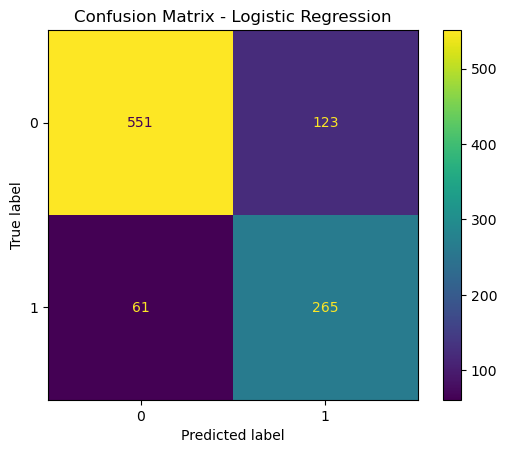

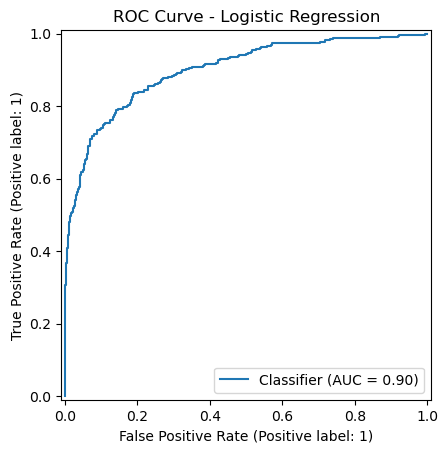


Feature Importance:
              Feature  Importance
5           npl_ratio    2.445556
4     liquidity_ratio    1.328029
3    capital_adequacy    0.547082
2      total_deposits    0.195896
1         total_loans    0.191400
8    loan_asset_ratio    0.060158
10       asset_growth    0.051828
9      deposit_growth    0.046424
0        total_assets    0.039376
6                 roa    0.018119
7   operating_expense    0.012738


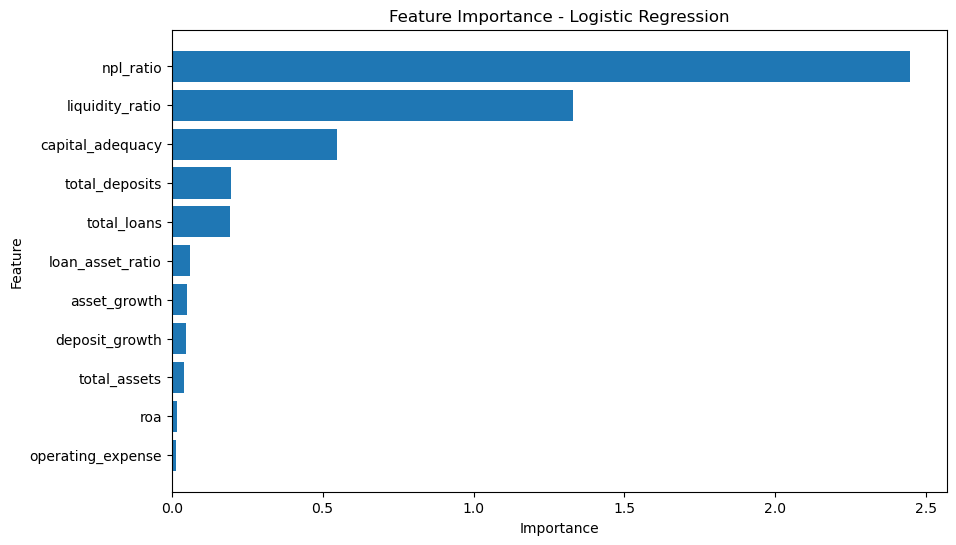


Generating SHAP explanations for Logistic Regression...


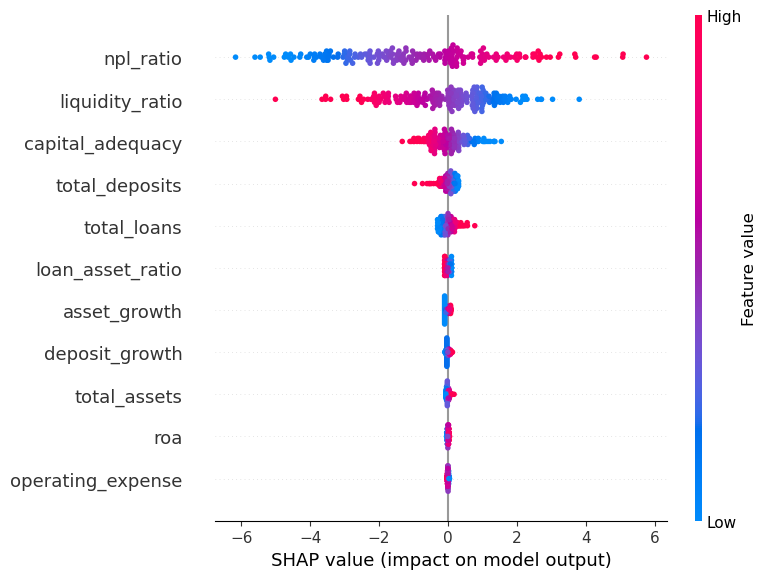


MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



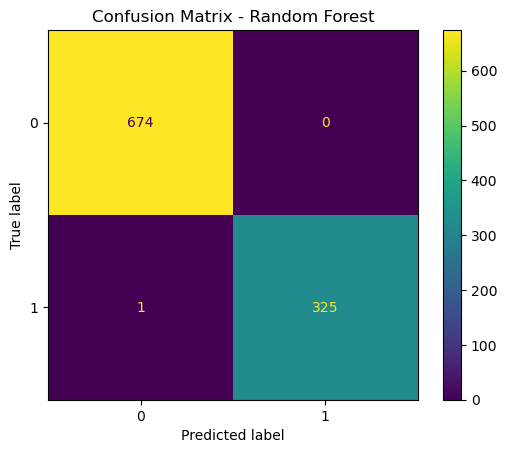

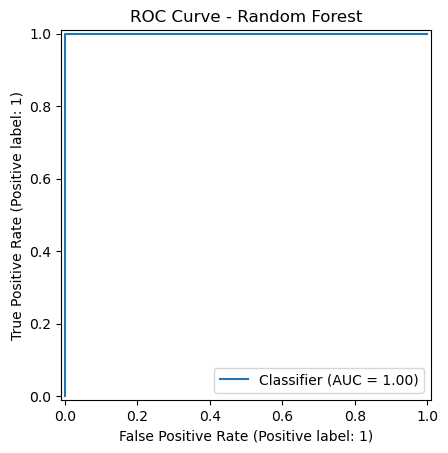


Feature Importance:
              Feature  Importance
5           npl_ratio    0.631529
4     liquidity_ratio    0.272664
3    capital_adequacy    0.064708
8    loan_asset_ratio    0.005074
1         total_loans    0.004115
0        total_assets    0.003988
6                 roa    0.003943
2      total_deposits    0.003731
7   operating_expense    0.003699
10       asset_growth    0.003277
9      deposit_growth    0.003272


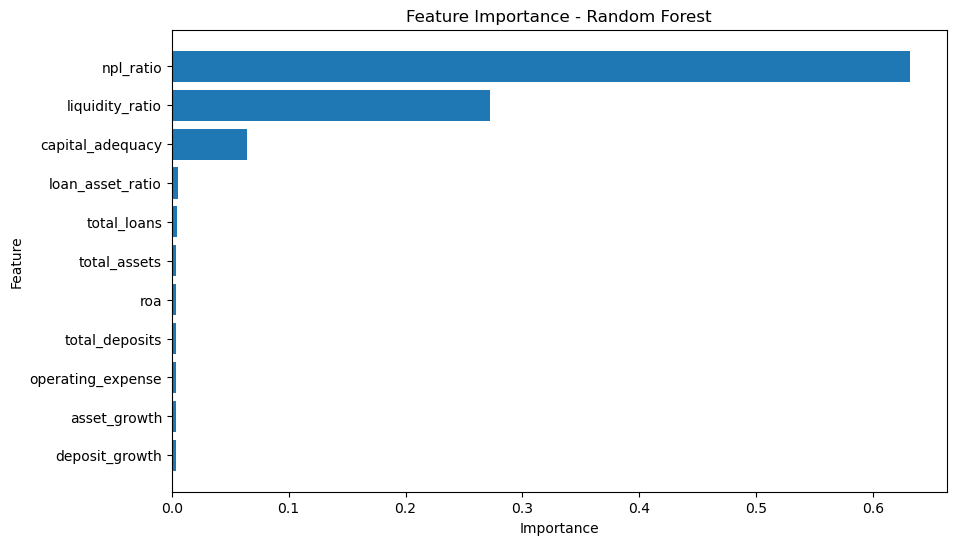


Generating SHAP explanations for Random Forest...


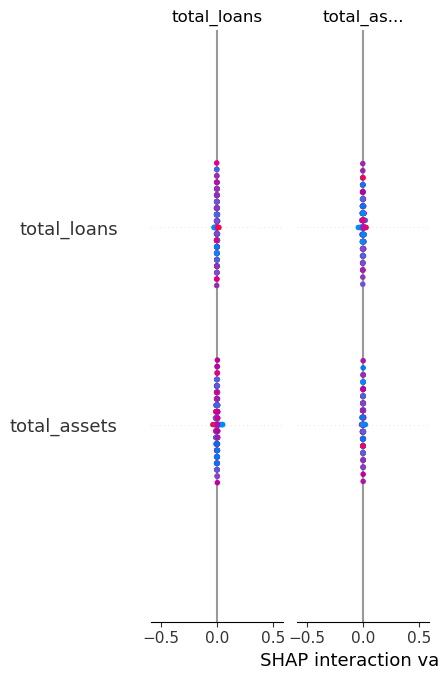


MODEL: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       674
           1       0.99      1.00      0.99       326

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



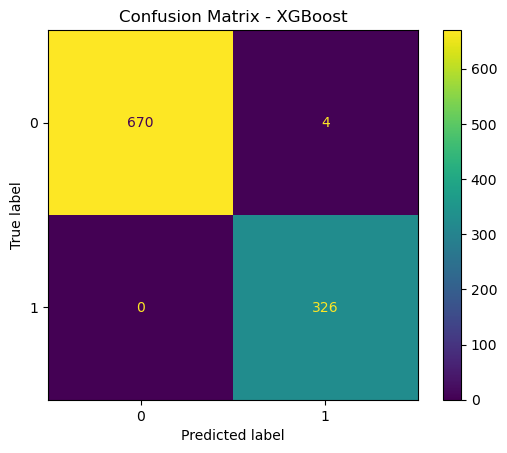

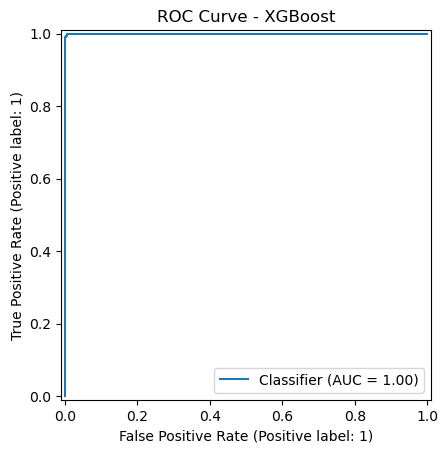


Feature Importance:
              Feature  Importance
5           npl_ratio    0.554337
4     liquidity_ratio    0.303033
3    capital_adequacy    0.096204
0        total_assets    0.008134
2      total_deposits    0.006954
8    loan_asset_ratio    0.005688
10       asset_growth    0.005524
7   operating_expense    0.005380
6                 roa    0.005068
1         total_loans    0.004861
9      deposit_growth    0.004816


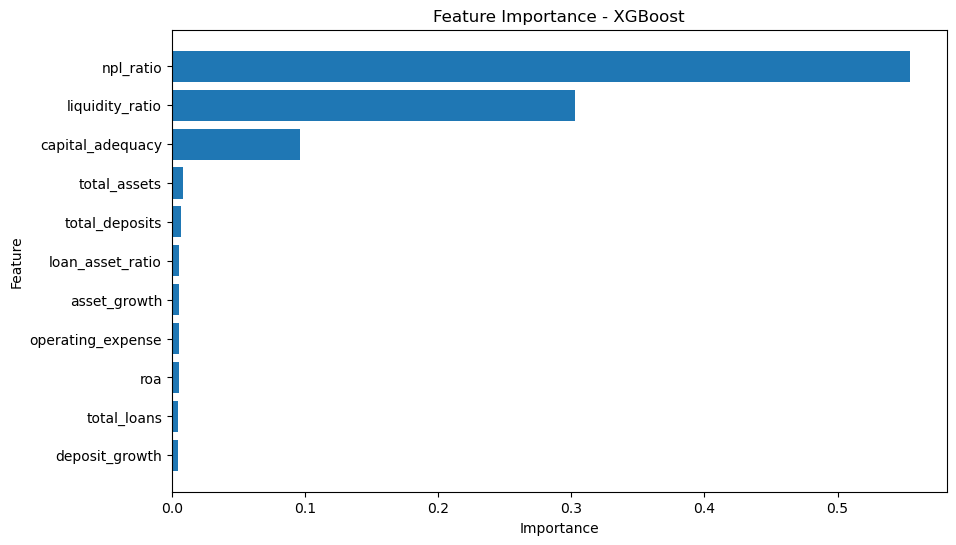


Generating SHAP explanations for XGBoost...


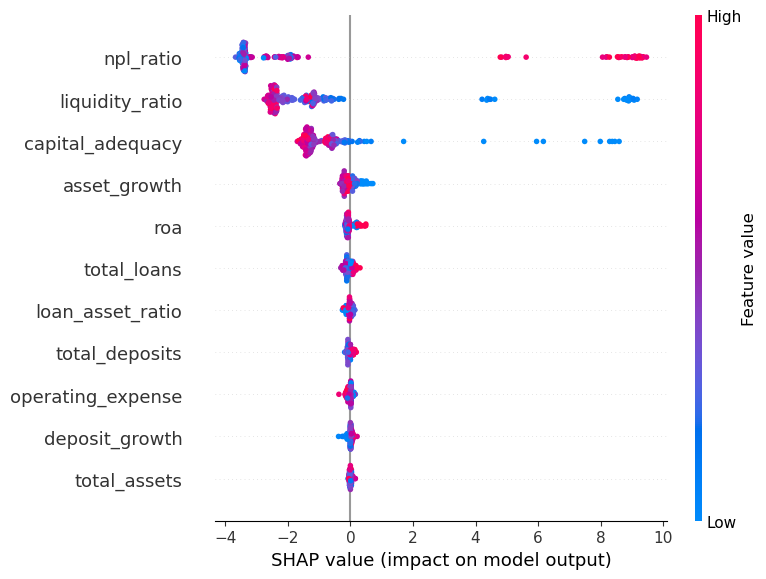


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1        Random Forest     0.999   1.000000  0.996933  0.998464  1.000000
2              XGBoost     0.996   0.987879  1.000000  0.993902  0.999964
0  Logistic Regression     0.816   0.682990  0.812883  0.742297  0.899833

Results saved to: model_results_comparison.xlsx


In [1]:
# ============================================
# FINANCIAL DISTRESS PREDICTION FOR SACCOs
# Using the generated realistic SACCO dataset
# Adds:
# 1. Feature importance
# 2. SHAP explanations
# 3. Confusion matrix
# 4. ROC curves
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Explainability
import shap

# ============================================
# 1. LOAD DATA
# ============================================
file_path = r"C:/Users/User/OneDrive/Documents/My Writings/Dissertation/sacco_dataset.xlsx"  # change path if needed
df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
print(df.head())

# ============================================
# 2. DEFINE FEATURES AND TARGET
# ============================================
# Exclude identifiers and target
drop_cols = ["sacco_id", "year", "distress"]
X = df.drop(columns=drop_cols)
y = df["distress"]

feature_names = X.columns.tolist()

print("\nFeatures used:")
print(feature_names)

# ============================================
# 3. TRAIN-TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================
# 4. SCALE DATA
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

# ============================================
# 5. HANDLE CLASS IMBALANCE
# ============================================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled_df, y_train)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# ============================================
# 6. DEFINE MODELS
# ============================================
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )
}

# ============================================
# 7. TRAIN, EVALUATE, PLOT
# ============================================
results = []

for name, model in models.items():
    print("\n" + "=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    # Train
    model.fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = model.predict(X_test_scaled_df)
    y_prob = model.predict_proba(X_test_scaled_df)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # ----------------------------------------
    # 7A. Confusion Matrix
    # ----------------------------------------
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ----------------------------------------
    # 7B. ROC Curve
    # ----------------------------------------
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve - {name}")
    plt.show()

    # ----------------------------------------
    # 7C. Feature Importance
    # ----------------------------------------
    print("\nFeature Importance:")

    if name == "Logistic Regression":
        importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance": np.abs(model.coef_[0])
        }).sort_values(by="Importance", ascending=False)

    else:
        importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        }).sort_values(by="Importance", ascending=False)

    print(importance)

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(importance["Feature"], importance["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance - {name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

    # ----------------------------------------
    # 7D. SHAP Explanations
    # ----------------------------------------
    print(f"\nGenerating SHAP explanations for {name}...")

    try:
        # Use small sample for speed
        shap_sample = X_test_scaled_df.sample(
            n=min(200, len(X_test_scaled_df)),
            random_state=42
        )

        if name == "Logistic Regression":
            explainer = shap.Explainer(model, X_train_resampled)
            shap_values = explainer(shap_sample)

        elif name in ["Random Forest", "XGBoost"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(shap_sample)

            # XGBoost / RF may return list for binary classes
            if isinstance(shap_values, list):
                shap_values = shap_values[1]

        # Summary plot
        shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, show=True)

    except Exception as e:
        print(f"SHAP could not be generated for {name}. Error: {e}")

# ============================================
# 8. MODEL COMPARISON TABLE
# ============================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results_df.sort_values(by="ROC-AUC", ascending=False))

# ============================================
# 9. OPTIONAL: SAVE RESULTS
# ============================================
results_df.to_excel("model_results_comparison.xlsx", index=False)
print("\nResults saved to: model_results_comparison.xlsx")

LSTM Model

Dataset shape: (5000, 14)
   sacco_id  year  total_assets   total_loans  total_deposits  \
0         1  2015  1.935247e+09  1.470399e+09    1.586383e+09   
1         1  2016  2.213134e+09  1.498898e+09    1.630374e+09   
2         1  2017  2.530924e+09  1.877384e+09    1.842257e+09   
3         1  2018  2.894347e+09  2.138524e+09    2.052932e+09   
4         1  2019  3.309955e+09  2.491188e+09    2.608345e+09   

   capital_adequacy  liquidity_ratio  npl_ratio       roa  operating_expense  \
0          0.152975         0.190635   0.133169  0.065349           0.267137   
1          0.176277         0.209678  -0.006531  0.015502           0.260640   
2          0.132759         0.143508   0.128626  0.045484           0.304727   
3          0.117258         0.153960   0.085028  0.037987           0.279581   
4          0.159595         0.157692   0.102902  0.025583           0.314620   

   distress  loan_asset_ratio  deposit_growth  asset_growth  
0         1          0.759799        0.0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6156 - loss: 0.6771 - val_accuracy: 0.7250 - val_loss: 0.6166
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6812 - loss: 0.6357 - val_accuracy: 0.7250 - val_loss: 0.5929
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6719 - loss: 0.6202 - val_accuracy: 0.7250 - val_loss: 0.5882
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6812 - loss: 0.5969 - val_accuracy: 0.7250 - val_loss: 0.5788
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7219 - loss: 0.5621 - val_accuracy: 0.7250 - val_loss: 0.5764
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7406 - loss: 0.5225 - val_accuracy: 0.7250 - val_loss: 0.5635
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7375 - loss: 0.5138 - val_accuracy: 0.7250 - val_loss: 0.5718
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7781 - loss: 0.4771 - val_accuracy: 0.7250 - 

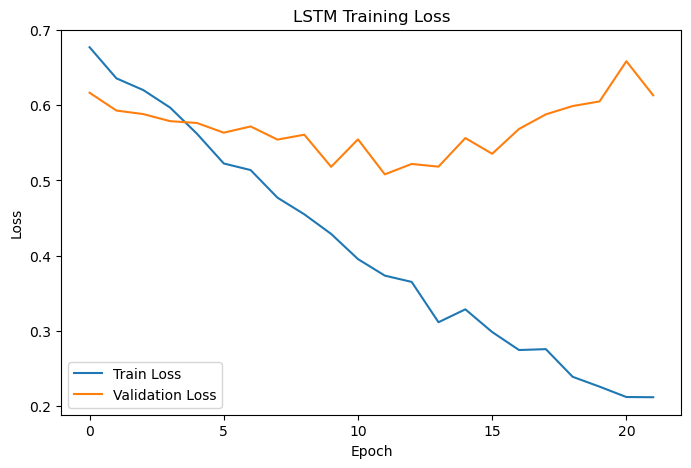

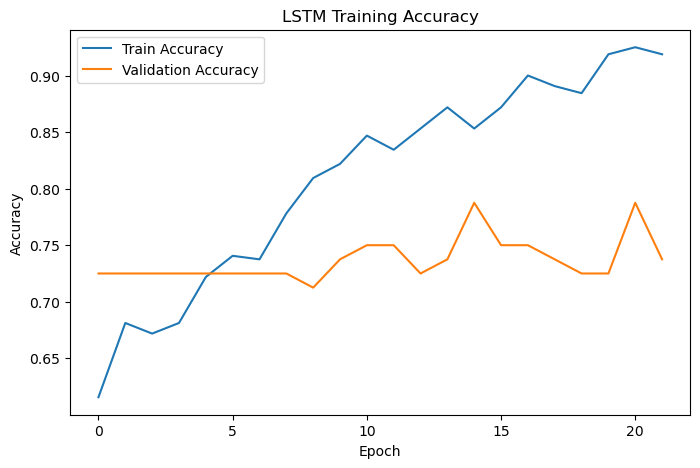

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step 

LSTM Results
Accuracy : 0.7700
Precision: 0.7500
Recall   : 0.5676
F1-Score : 0.6462
ROC-AUC  : 0.8271

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        63
           1       0.75      0.57      0.65        37

    accuracy                           0.77       100
   macro avg       0.76      0.73      0.74       100
weighted avg       0.77      0.77      0.76       100



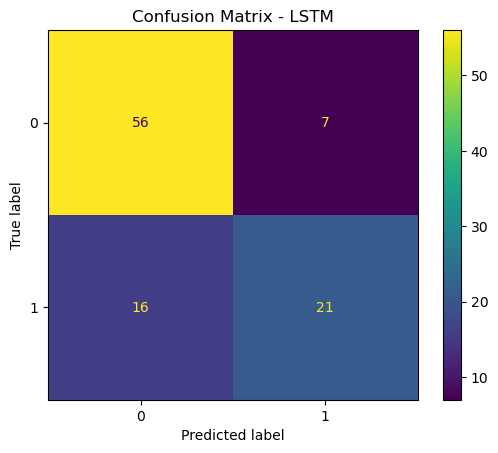

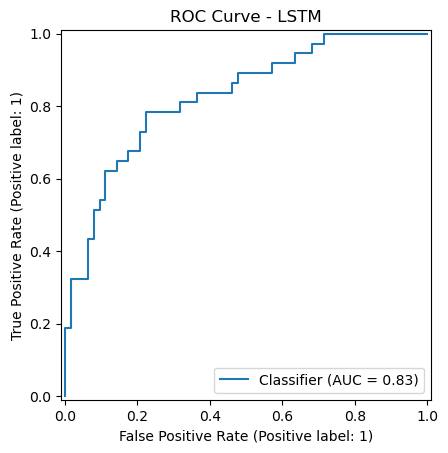

In [4]:
# ============================================
# LSTM MODEL FOR FINANCIAL DISTRESS PREDICTION
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# ============================================
# 1. LOAD DATA
# ============================================
file_path = r"C:/Users/User/OneDrive/Documents/My Writings/Dissertation/sacco_dataset.xlsx"
df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
print(df.head())

# ============================================
# 2. SORT DATA
# ============================================
df = df.sort_values(["sacco_id", "year"]).reset_index(drop=True)

# ============================================
# 3. SELECT FEATURES
# ============================================
feature_cols = [
    "total_assets",
    "total_loans",
    "total_deposits",
    "capital_adequacy",
    "liquidity_ratio",
    "npl_ratio",
    "roa",
    "operating_expense",
    "loan_asset_ratio",
    "deposit_growth",
    "asset_growth"
]

target_col = "distress"

# ============================================
# 4. SCALE FEATURES
# ============================================
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# ============================================
# 5. BUILD SEQUENCES
# Each SACCO becomes one sequence across years
# ============================================
X_seq = []
y_seq = []
sacco_ids = []

for sacco_id, group in df.groupby("sacco_id"):
    group = group.sort_values("year")
    
    # keep only full 10-year histories if available
    if len(group) == 10:
        X_seq.append(group[feature_cols].values)
        y_seq.append(group[target_col].iloc[-1])   # predict distress at final year
        sacco_ids.append(sacco_id)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)   # (num_saccos, timesteps, features)
print("Target shape:", y_seq.shape)

# ============================================
# 6. TRAIN-TEST SPLIT BY SACCO
# ============================================
n_samples = len(X_seq)
split_index = int(n_samples * 0.8)

X_train = X_seq[:split_index]
X_test = X_seq[split_index:]

y_train = y_seq[:split_index]
y_test = y_seq[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ============================================
# 7. BUILD LSTM MODEL
# ============================================
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================
# 8. TRAIN MODEL
# ============================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ============================================
# 9. PLOT TRAINING HISTORY
# ============================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ============================================
# 10. EVALUATE MODEL
# ============================================
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_prob)

print("\nLSTM Results")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# ============================================
# 11. CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - LSTM")
plt.show()

# ============================================
# 12. ROC CURVE
# ============================================
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - LSTM")
plt.show()

Combined 4 models

clean, end-to-end script that compares all four models:

Logistic Regression
Random Forest
XGBoost
LSTM

It builds one final comparison table with:

Accuracy
Precision
Recall
F1-score
ROC-AUC

DATA PREVIEW
   sacco_id  year  total_assets   total_loans  total_deposits  \
0         1  2015  1.935247e+09  1.470399e+09    1.586383e+09   
1         1  2016  2.213134e+09  1.498898e+09    1.630374e+09   
2         1  2017  2.530924e+09  1.877384e+09    1.842257e+09   
3         1  2018  2.894347e+09  2.138524e+09    2.052932e+09   
4         1  2019  3.309955e+09  2.491188e+09    2.608345e+09   

   capital_adequacy  liquidity_ratio  npl_ratio       roa  operating_expense  \
0          0.152975         0.190635   0.133169  0.065349           0.267137   
1          0.176277         0.209678  -0.006531  0.015502           0.260640   
2          0.132759         0.143508   0.128626  0.045484           0.304727   
3          0.117258         0.153960   0.085028  0.037987           0.279581   
4          0.159595         0.157692   0.102902  0.025583           0.314620   

   distress  loan_asset_ratio  deposit_growth  asset_growth  
0         1          0.759799        0.000000      0.

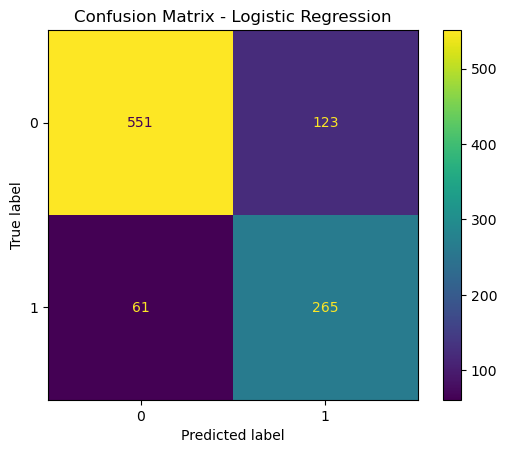

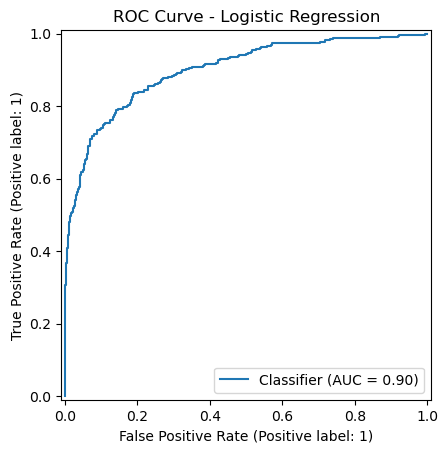


MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



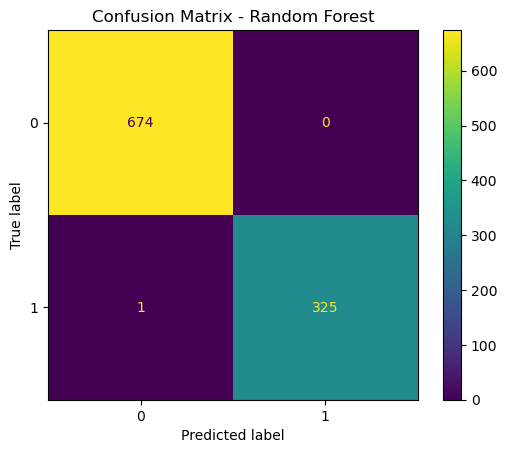

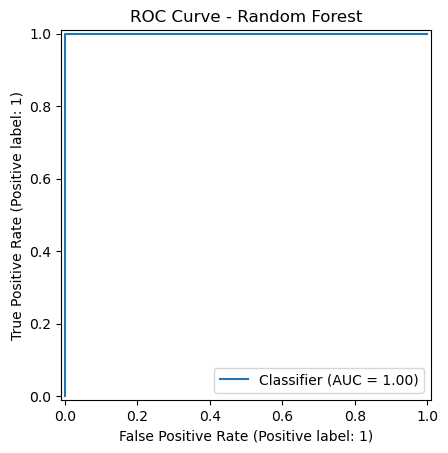


MODEL: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       674
           1       0.99      1.00      0.99       326

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



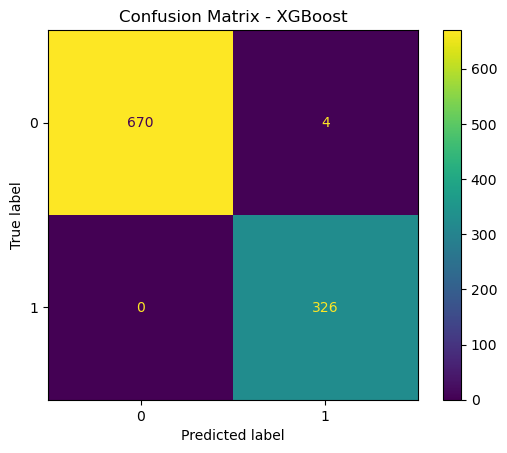

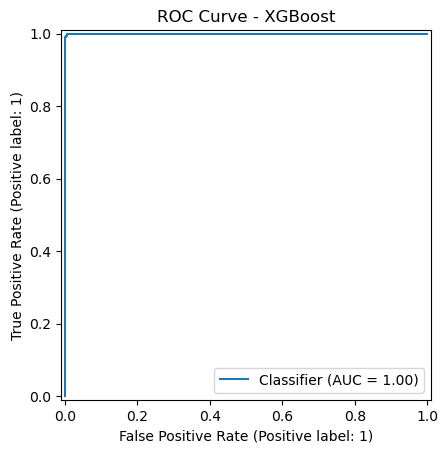


PREPARING LSTM DATA
LSTM sequence shape: (500, 9, 11)
LSTM target shape: (500,)
LSTM train shape: (400, 9, 11)
LSTM test shape : (100, 9, 11)
LSTM class weights: {np.int64(0): np.float64(0.7352941176470589), np.int64(1): np.float64(1.5625)}

MODEL: LSTM
Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5562 - loss: 0.7072 - val_accuracy: 0.6250 - val_loss: 0.6783
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5594 - loss: 0.6984 - val_accuracy: 0.5125 - val_loss: 0.6946
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5406 - loss: 0.6964 - val_accuracy: 0.5125 - val_loss: 0.6983
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5625 - loss: 0.6850 - val_accuracy: 0.4250 - val_loss: 0.7007
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5500 - loss: 0.6832 - val_accuracy: 0.3625 - val_loss: 0.7241
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5250 - loss: 0.6827 - val_accuracy: 0.3250

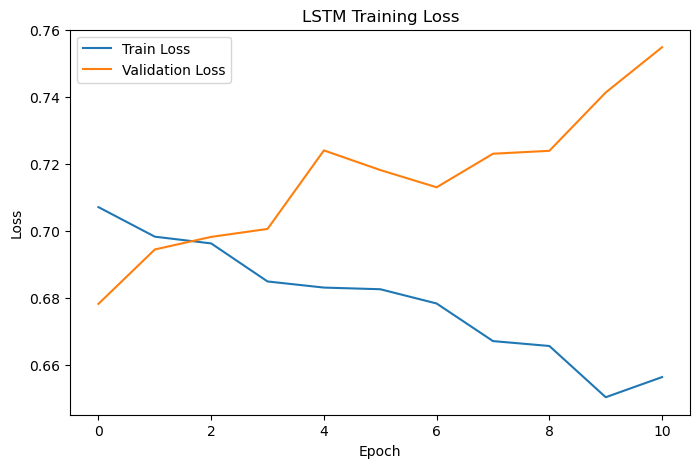

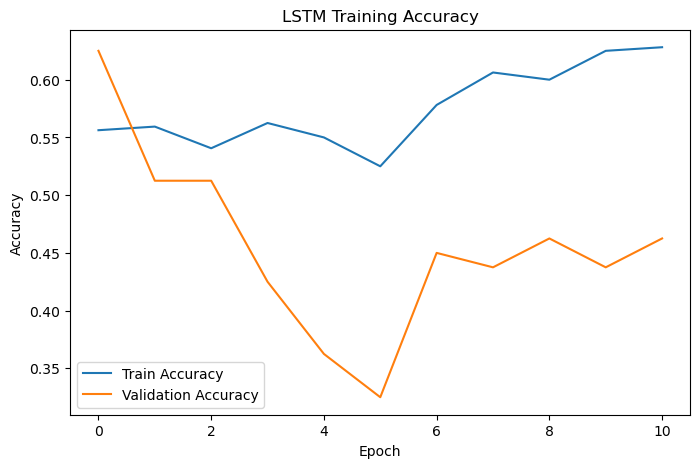

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step 

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.71      0.66        63
           1       0.33      0.24      0.28        37

    accuracy                           0.54       100
   macro avg       0.47      0.48      0.47       100
weighted avg       0.51      0.54      0.52       100



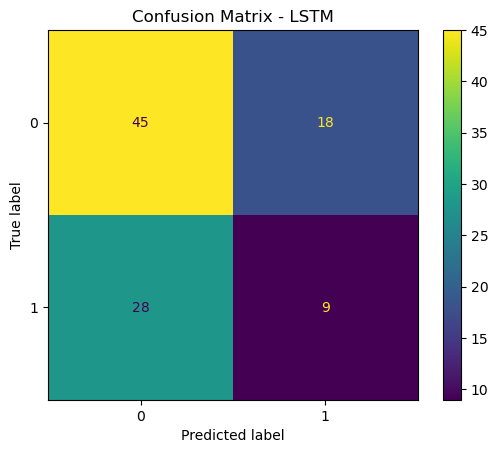

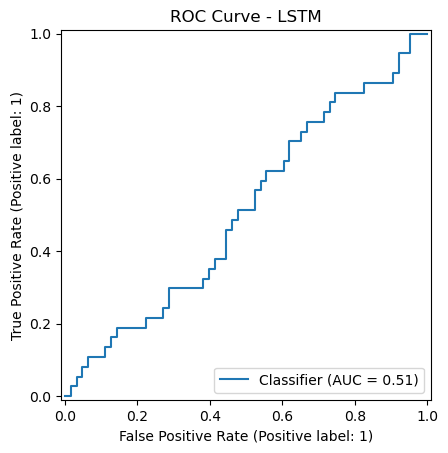


FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0        Random Forest     0.999   1.000000  0.996933  0.998464  1.000000
1              XGBoost     0.996   0.987879  1.000000  0.993902  0.999964
2  Logistic Regression     0.816   0.682990  0.812883  0.742297  0.899833
3                 LSTM     0.540   0.333333  0.243243  0.281250  0.512656

Comparison table saved as: final_model_comparison.xlsx


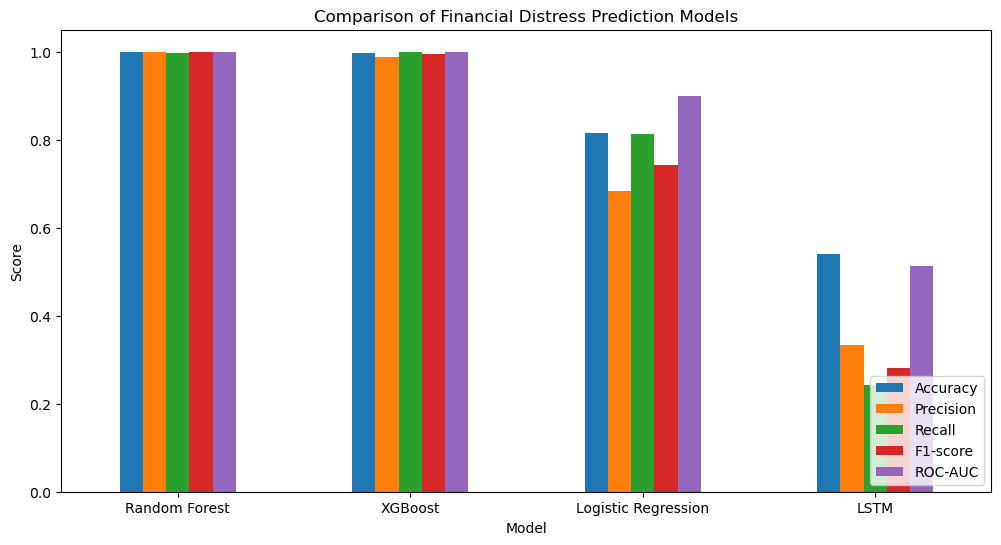

In [5]:
# =========================================================
# SACCO FINANCIAL DISTRESS PREDICTION - FULL MODEL COMPARISON
# Models:
# 1. Logistic Regression
# 2. Random Forest
# 3. XGBoost
# 4. LSTM
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SCIKIT-LEARN
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# =========================
# IMBALANCE HANDLING
# =========================
from imblearn.over_sampling import SMOTE

# =========================
# XGBOOST
# =========================
from xgboost import XGBClassifier

# =========================
# DEEP LEARNING
# =========================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# 1. LOAD DATA
# =========================================================
file_path = r"C:/Users/User/OneDrive/Documents/My Writings/Dissertation/sacco_dataset.xlsx"
df = pd.read_excel(file_path)

print("=" * 70)
print("DATA PREVIEW")
print("=" * 70)
print(df.head())
print("\nDataset shape:", df.shape)

# =========================================================
# 2. PREPARE TABULAR DATA FOR LOGISTIC/RF/XGBOOST
# =========================================================
tabular_drop_cols = ["sacco_id", "year", "distress"]
X = df.drop(columns=tabular_drop_cols)
y = df["distress"]

feature_names = X.columns.tolist()

# Train-test split for tabular models
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

# Handle imbalance using SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled_df, y_train)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# =========================================================
# 3. DEFINE TABULAR MODELS
# =========================================================
tabular_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )
}

# =========================================================
# 4. TRAIN AND EVALUATE TABULAR MODELS
# =========================================================
results = []

for name, model in tabular_models.items():
    print("\n" + "=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_scaled_df)
    y_prob = model.predict_proba(X_test_scaled_df)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve - {name}")
    plt.show()

# =========================================================
# 5. PREPARE SEQUENCE DATA FOR LSTM
# =========================================================
print("\n" + "=" * 70)
print("PREPARING LSTM DATA")
print("=" * 70)

df_lstm = df.copy()
df_lstm = df_lstm.sort_values(["sacco_id", "year"]).reset_index(drop=True)

sequence_features = [
    "total_assets",
    "total_loans",
    "total_deposits",
    "capital_adequacy",
    "liquidity_ratio",
    "npl_ratio",
    "roa",
    "operating_expense",
    "loan_asset_ratio",
    "deposit_growth",
    "asset_growth"
]

target_col = "distress"

# Scale sequence features
lstm_scaler = StandardScaler()
df_lstm[sequence_features] = lstm_scaler.fit_transform(df_lstm[sequence_features])

# Build sequences:
# Input = 2015-2023
# Target = distress in 2024
X_seq = []
y_seq = []
sacco_ids = []

for sacco_id, group in df_lstm.groupby("sacco_id"):
    group = group.sort_values("year")

    if len(group) == 10:
        X_seq.append(group[sequence_features].iloc[:-1].values)  # first 9 years
        y_seq.append(group[target_col].iloc[-1])                 # final year target
        sacco_ids.append(sacco_id)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("LSTM sequence shape:", X_seq.shape)
print("LSTM target shape:", y_seq.shape)

# Train-test split for LSTM (by SACCO sequence)
split_index = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:split_index]
X_test_lstm = X_seq[split_index:]

y_train_lstm = y_seq[:split_index]
y_test_lstm = y_seq[split_index:]

print("LSTM train shape:", X_train_lstm.shape)
print("LSTM test shape :", X_test_lstm.shape)

# Class weights for imbalanced sequence data
classes = np.unique(y_train_lstm)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_lstm
)
class_weights = {cls: weight for cls, weight in zip(classes, class_weights_array)}
print("LSTM class weights:", class_weights)

# =========================================================
# 6. BUILD, TRAIN, AND EVALUATE LSTM
# =========================================================
print("\n" + "=" * 70)
print("MODEL: LSTM")
print("=" * 70)

lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Evaluate LSTM
y_prob_lstm = lstm_model.predict(X_test_lstm).flatten()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

acc = accuracy_score(y_test_lstm, y_pred_lstm)
prec = precision_score(y_test_lstm, y_pred_lstm, zero_division=0)
rec = recall_score(y_test_lstm, y_pred_lstm, zero_division=0)
f1 = f1_score(y_test_lstm, y_pred_lstm, zero_division=0)
roc = roc_auc_score(y_test_lstm, y_prob_lstm)

results.append(["LSTM", acc, prec, rec, f1, roc])

print("\nClassification Report:")
print(classification_report(y_test_lstm, y_pred_lstm, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test_lstm, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - LSTM")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test_lstm, y_prob_lstm)
plt.title("ROC Curve - LSTM")
plt.show()

# =========================================================
# 7. FINAL MODEL COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
)

results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
print(results_df)

# =========================================================
# 8. SAVE RESULTS
# =========================================================
results_df.to_excel("final_model_comparison.xlsx", index=False)
print("\nComparison table saved as: final_model_comparison.xlsx")

# =========================================================
# 9. OPTIONAL BAR CHART FOR MODEL COMPARISON
# =========================================================
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

results_plot = results_df.set_index("Model")[metrics_to_plot]
results_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Comparison of Financial Distress Prediction Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.show()

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure dataset is loaded as df
# df = your dataset

variables = [
    "npl_ratio",
    "liquidity_ratio",
    "capital_adequacy",
    "loan_asset_ratio",
    "roa",
    "operating_expense"
]

# Boxplots for each variable
for var in variables:
    plt.figure()
    sns.boxplot(x="distress", y=var, data=df)
    plt.title(f"{var} vs Financial Distress")
    plt.xlabel("Distress (0 = No, 1 = Yes)")
    plt.ylabel(var)
    plt.savefig(f"{var}_boxplot.png")
    plt.close()

# Distribution plots
for var in variables:
    plt.figure()
    sns.kdeplot(data=df, x=var, hue="distress", fill=True)
    plt.title(f"Distribution of {var} by Distress Status")
    plt.savefig(f"{var}_distribution.png")
    plt.close()

DATA PREVIEW
   sacco_id  year  total_assets   total_loans  total_deposits  \
0         1  2015  1.935247e+09  1.470399e+09    1.586383e+09   
1         1  2016  2.213134e+09  1.498898e+09    1.630374e+09   
2         1  2017  2.530924e+09  1.877384e+09    1.842257e+09   
3         1  2018  2.894347e+09  2.138524e+09    2.052932e+09   
4         1  2019  3.309955e+09  2.491188e+09    2.608345e+09   

   capital_adequacy  liquidity_ratio  npl_ratio       roa  operating_expense  \
0          0.152975         0.190635   0.133169  0.065349           0.267137   
1          0.176277         0.209678  -0.006531  0.015502           0.260640   
2          0.132759         0.143508   0.128626  0.045484           0.304727   
3          0.117258         0.153960   0.085028  0.037987           0.279581   
4          0.159595         0.157692   0.102902  0.025583           0.314620   

   distress  loan_asset_ratio  deposit_growth  asset_growth  
0         1          0.759799        0.000000      0.

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 800x600 with 0 Axes>

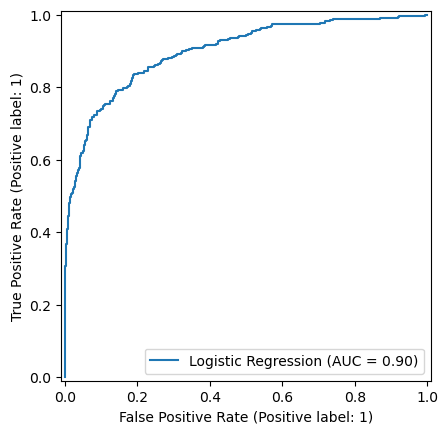

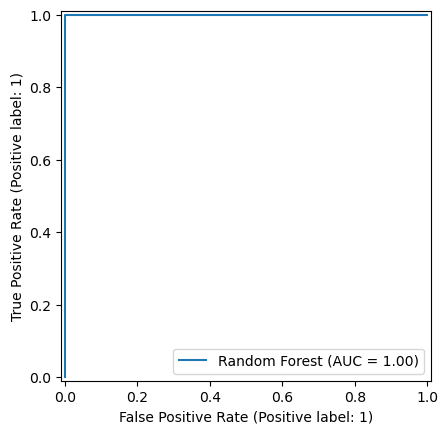

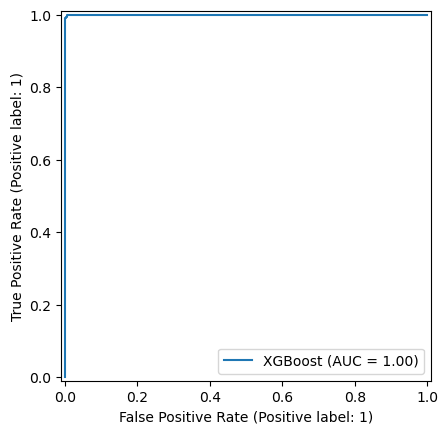

In [7]:
# =========================================================
# SACCO FINANCIAL DISTRESS PREDICTION - FULL MODEL COMPARISON
# Models:
# 1. Logistic Regression
# 2. Random Forest
# 3. XGBoost
# 4. LSTM
# Saves all plots as PNG
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SCIKIT-LEARN
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# =========================
# IMBALANCE HANDLING
# =========================
from imblearn.over_sampling import SMOTE

# =========================
# XGBOOST
# =========================
from xgboost import XGBClassifier

# =========================
# DEEP LEARNING
# =========================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# 0. OUTPUT FOLDER
# =========================================================  
output_dir = "model_outputs"
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# 1. LOAD DATA 
# =========================================================
file_path = r"C:/Users/User/OneDrive/Documents/My Writings/Dissertation/sacco_dataset.xlsx"
df = pd.read_excel(file_path)

print("=" * 70)
print("DATA PREVIEW")
print("=" * 70)
print(df.head())
print("\nDataset shape:", df.shape)

# =========================================================
# 2. PREPARE TABULAR DATA FOR LOGISTIC/RF/XGBOOST
# ========================================================= 
tabular_drop_cols = ["sacco_id", "year", "distress"]
X = df.drop(columns=tabular_drop_cols)
y = df["distress"]

feature_names = X.columns.tolist()

# Train-test split for tabular models
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

# Handle imbalance using SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled_df, y_train)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# =========================================================
# 3. DEFINE TABULAR MODELS
# =========================================================
tabular_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )
}

# =========================================================
# 4. TRAIN AND EVALUATE TABULAR MODELS
# =========================================================
results = []
trained_models = {}

for name, model in tabular_models.items():
    print("\n" + "=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled_df)
    y_prob = model.predict_proba(X_test_scaled_df)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{name.lower().replace(' ', '_')}_confusion_matrix.png"), dpi=300)
    plt.close()

    # ROC Curve
    plt.figure(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve - {name}")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{name.lower().replace(' ', '_')}_roc_curve.png"), dpi=300)
    plt.close()

# =========================================================
# 5. FEATURE IMPORTANCE PLOT
# =========================================================
# Using Random Forest as the main feature importance model
rf_model = trained_models["Random Forest"]

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance_df)

feature_importance_df.to_excel(
    os.path.join(output_dir, "feature_importance_table.xlsx"),
    index=False
)

plt.figure(figsize=(10, 6))
top_n = feature_importance_df.head(10).sort_values(by="Importance", ascending=True)
plt.barh(top_n["Feature"], top_n["Importance"])
plt.title("Feature Importance for Financial Distress Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "feature_importance_plot.png"), dpi=300)
plt.close()

# =========================================================
# 6. PREPARE SEQUENCE DATA FOR LSTM
# =========================================================
print("\n" + "=" * 70)
print("PREPARING LSTM DATA")
print("=" * 70)

df_lstm = df.copy()
df_lstm = df_lstm.sort_values(["sacco_id", "year"]).reset_index(drop=True)

sequence_features = [
    "total_assets",
    "total_loans",
    "total_deposits",
    "capital_adequacy",
    "liquidity_ratio",
    "npl_ratio",
    "roa",
    "operating_expense",
    "loan_asset_ratio",
    "deposit_growth",
    "asset_growth"
]

target_col = "distress"

# Scale sequence features
lstm_scaler = StandardScaler()
df_lstm[sequence_features] = lstm_scaler.fit_transform(df_lstm[sequence_features])

# Build sequences:
# Input = 2015-2023
# Target = distress in 2024
X_seq = []
y_seq = []
sacco_ids = []

for sacco_id, group in df_lstm.groupby("sacco_id"):
    group = group.sort_values("year")

    if len(group) == 10:
        X_seq.append(group[sequence_features].iloc[:-1].values)
        y_seq.append(group[target_col].iloc[-1])
        sacco_ids.append(sacco_id)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("LSTM sequence shape:", X_seq.shape)
print("LSTM target shape:", y_seq.shape)

# Train-test split for LSTM
split_index = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:split_index]
X_test_lstm = X_seq[split_index:]

y_train_lstm = y_seq[:split_index]
y_test_lstm = y_seq[split_index:]

print("LSTM train shape:", X_train_lstm.shape)
print("LSTM test shape :", X_test_lstm.shape)

# Class weights for imbalanced sequence data
classes = np.unique(y_train_lstm)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_lstm
)
class_weights = {cls: weight for cls, weight in zip(classes, class_weights_array)}
print("LSTM class weights:", class_weights)

# =========================================================
# 7. BUILD, TRAIN, AND EVALUATE LSTM
# =========================================================
print("\n" + "=" * 70)
print("MODEL: LSTM")
print("=" * 70)

lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

# Plot LSTM training loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "lstm_training_loss.png"), dpi=300)
plt.close()

# Plot LSTM training accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "lstm_training_accuracy.png"), dpi=300)
plt.close()

# Evaluate LSTM
y_prob_lstm = lstm_model.predict(X_test_lstm).flatten()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

acc = accuracy_score(y_test_lstm, y_pred_lstm)
prec = precision_score(y_test_lstm, y_pred_lstm, zero_division=0)
rec = recall_score(y_test_lstm, y_pred_lstm, zero_division=0)
f1 = f1_score(y_test_lstm, y_pred_lstm, zero_division=0)
roc = roc_auc_score(y_test_lstm, y_prob_lstm)

results.append(["LSTM", acc, prec, rec, f1, roc])

print("\nClassification Report:")
print(classification_report(y_test_lstm, y_pred_lstm, zero_division=0))

# Confusion Matrix - LSTM
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_lstm, y_pred_lstm))
disp.plot()
plt.title("Confusion Matrix - LSTM")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "lstm_confusion_matrix.png"), dpi=300)
plt.close()

# ROC Curve - LSTM
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_lstm, y_prob_lstm)
plt.title("ROC Curve - LSTM")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "lstm_roc_curve.png"), dpi=300)
plt.close()

# =========================================================
# 8. FINAL MODEL COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
)

results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
print(results_df)

results_df.to_excel(os.path.join(output_dir, "final_model_comparison.xlsx"), index=False)

# =========================================================
# 9. MODEL COMPARISON BAR CHART
# =========================================================
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

results_plot = results_df.set_index("Model")[metrics_to_plot]
ax = results_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Comparison of Financial Distress Prediction Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "model_performance_comparison.png"), dpi=300)
plt.close()

# =========================================================
# 10. COMBINED ROC CURVE FOR ALL MODELS
# =========================================================
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_scaled_df)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name)

RocCurveDisplay.from_predictions(y_test_lstm, y_prob_lstm, name="LSTM")

plt.title("ROC Curves for Financial Distress Models")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "combined_roc_curves.png"), dpi=300)
plt.close()

# =========================================================
# 11. VARIABLE VISUALIZATION BY DISTRESS STATUS
# =========================================================
variables_to_plot = [
    "npl_ratio",
    "liquidity_ratio",
    "capital_adequacy",
    "loan_asset_ratio",
    "roa",
    "operating_expense"
]

for var in variables_to_plot:
    plt.figure(figsize=(7, 5))

    group_0 = df[df["distress"] == 0][var]
    group_1 = df[df["distress"] == 1][var]

    plt.boxplot(
        [group_0, group_1],
        tick_labels=["Non-distressed", "Distressed"]
    )
    plt.title(f"{var.replace('_', ' ').title()} by Distress Status")
    plt.ylabel(var.replace("_", " ").title())
    plt.xlabel("Distress Status")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{var}_boxplot.png"), dpi=300)
    plt.close()

# =========================================================
# 12. SAVE FEATURE IMPORTANCE OF TOP VARIABLES ONLY
# =========================================================
top_features = feature_importance_df.head(10)
top_features.to_excel(
    os.path.join(output_dir, "top_10_feature_importance.xlsx"),
    index=False
)

print("\nAll results, tables, and PNG plots have been saved in:")
print(os.path.abspath(output_dir))